# Scraping Land Processing: limpieza, estandarización y eliminación de outliers

Notebook para limpiar `scraping_land_raw.csv` con foco en nulos, tipado, estandarización de `tipo_suelo`, variables derivadas y depuración de outliers.

**Trazabilidad:** cada acción genera un dataframe nuevo; no se reasigna `df`.

**Output:** `data/processed/scraping_manual/scraping_land_processed.csv`

In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd


## Carga del dataset

Se lee el CSV desde el repositorio para trabajar siempre con la versión local de esta rama.


In [2]:
csv_candidates = [
    Path("../../data/raw/scraping_manual/scraping_land_raw.csv"),
    Path("data/raw/scraping_manual/scraping_land_raw.csv")
]
csv_path = next((path for path in csv_candidates if path.exists()), csv_candidates[0])

# Leemos el raw original (no se modifica nunca en disco).
df_raw_original = pd.read_csv(
    csv_path,
    delimiter=";",
    on_bad_lines="warn",
    encoding="utf-8",
    encoding_errors="replace",
    skipinitialspace=True,
    index_col=0
)

# Copia de trabajo: toda la limpieza del notebook se aplica sobre esta copia.
df_raw = df_raw_original.copy(deep=True)

print(f"CSV cargado desde: {csv_path}")
print(f"Filas: {len(df_raw):,} | Columnas: {df_raw.shape[1]}")
df_raw.head(3)

CSV cargado desde: ../../data/raw/scraping_manual/scraping_land_raw.csv
Filas: 1,080 | Columnas: 11


,anunciante,titulo,municipio,zona,precio_eur,precio_anterior_eur,descuento_pct,superficie_m2,tipo_suelo,referencia_catastral,notas
id,,,,,,,,,,,
1,Exclusivas inmobiliarias mikeli,"Terreno en Barrio Llanilla, Alisal - Cazoña - ...",Santander,"Barrio Llanilla, Alisal - Cazoña - San Román",430000,NaN,NaN,972,NaN,NaN,NaN
2,MENA INMOBILIARIA,"Terreno en Oruña, Piélagos",Piélagos,Oruña,139000,NaN,NaN,965,Urbano (solar),NaN,Edificabilidad 200 m²
3,Grupo Inmobiliario Tribeca,"Terreno en Peñacastillo - Nuevamontaña, Santander",Santander,Peñacastillo - Nuevamontaña,169000,NaN,NaN,650,Urbano (solar),NaN,5 parcelas


## Normalización inicial y tratamiento de nulos

1. Se limpia texto (espacios).
2. Se convierten marcadores vacíos a nulo real (`NaN`).
3. Se identifican registros con al menos una variable nula.


In [3]:
# Estandarizar vacíos y marcadores de no dato en todo el dataframe.
missing_tokens = {
    "", " ", "na", "n/a", "none", "null", "nan", "-", "--", "sin dato", "no informado"
}

df_clean = df_raw.copy()

for col in df_clean.columns:
    if df_clean[col].dtype == "object":
        df_clean[col] = df_clean[col].astype(str).str.strip()
        df_clean[col] = df_clean[col].replace({token: np.nan for token in missing_tokens})

# Máscara de registros incompletos (alguna variable nula).
mask_registro_incompleto = df_clean.isna().any(axis=1)

print("Registros con al menos un nulo:", int(mask_registro_incompleto.sum()))
print("Porcentaje sobre total:", round(mask_registro_incompleto.mean() * 100, 2), "%")

df_clean.loc[mask_registro_incompleto].head(10)


Registros con al menos un nulo: 1079
Porcentaje sobre total: 99.91 %


,anunciante,titulo,municipio,zona,precio_eur,precio_anterior_eur,descuento_pct,superficie_m2,tipo_suelo,referencia_catastral,notas
id,,,,,,,,,,,
1,Exclusivas inmobiliarias mikeli,"Terreno en Barrio Llanilla, Alisal - Cazoña - ...",Santander,"Barrio Llanilla, Alisal - Cazoña - San Román",430000,NaN,NaN,972,NaN,NaN,NaN
2,MENA INMOBILIARIA,"Terreno en Oruña, Piélagos",Piélagos,Oruña,139000,NaN,NaN,965,Urbano (solar),NaN,Edificabilidad 200 m²
3,Grupo Inmobiliario Tribeca,"Terreno en Peñacastillo - Nuevamontaña, Santander",Santander,Peñacastillo - Nuevamontaña,169000,NaN,NaN,650,Urbano (solar),NaN,5 parcelas
4,Exclusivas inmobiliarias mikeli,"Terreno en Calle de la Arnia, Soto de la Marin...",Santa Cruz de Bezana,"Calle de la Arnia, Soto de la Marina",1290000,NaN,NaN,3217,NaN,NaN,Parcela urbana
5,Exclusivas inmobiliarias mikeli,"Terreno en Calle Barrio San Roque, Polanco",Polanco,Calle Barrio San Roque,80000,NaN,NaN,1668,NaN,NaN,820 urbanos + 848 rústicos
6,Exclusivas inmobiliarias mikeli,"Terreno en Avenida Playa San Juan de la Canal,...",Santa Cruz de Bezana,"Av. Playa San Juan de la Canal, Soto de la Marina",1500000,NaN,NaN,6518,NaN,NaN,3.433 urbanos
7,Bahía Home,"Terreno en Barrio la Venera, Oruña, Piélagos",Piélagos,"Barrio la Venera, Oruña",98000,NaN,NaN,4507,Urbanizable,NaN,Licencia + proyecto
8,Distrito inmobiliario,"Terreno en Barrio Mar, 87 --81, Polanco",Polanco,"Barrio Mar, 87 --81",132000,140000.0,6.0,2210,Urbano (solar),NaN,Licencia + proyecto básico
9,RE/MAX Vértice,"Terreno en Sv-4713, 12, Miengo",Miengo,"Sv-4713, 12",300000,NaN,NaN,6548,No urbanizable,NaN,Proyecto hotel canino


## Tipado y saneamiento de variables numéricas

Se fuerzan a numérico las variables cuantitativas; cualquier texto o formato inválido se transforma en nulo.


In [4]:
def to_numeric_strict(series: pd.Series) -> pd.Series:
    # Convierte texto a número; si hay texto no numérico, deja NaN.
    cleaned = (
        series.astype(str)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
        .str.replace(r"[^0-9,.-]", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    return pd.to_numeric(cleaned, errors="coerce")

df_typed = df_clean.copy()

numeric_cols = ["precio_eur", "precio_anterior_eur", "descuento_pct", "superficie_m2"]

print(df_typed[numeric_cols].dtypes)
df_typed[numeric_cols].describe(include="all").T


precio_eur               int64
precio_anterior_eur    float64
descuento_pct          float64
superficie_m2            int64
dtype: object


,count,mean,std,min,25%,50%,75%,max
precio_eur,1080.0,246821.639815,330320.655220,1200.0,76692.25,140000.0,269000.0,2900000.0
precio_anterior_eur,35.0,191800.000000,172224.017933,58900.0,90900.00,125000.0,200000.0,695000.0
descuento_pct,35.0,13.771429,12.567666,2.0,5.00,10.0,18.0,50.0
superficie_m2,1080.0,6580.628704,12985.475222,1.0,1350.00,2934.0,6000.0,150000.0


## Eliminación de columna no requerida

Se elimina la variable `zona` como pediste.


In [5]:
df_nozona = df_typed.copy()

if "zona" in df_nozona.columns:
    df_nozona = df_nozona.drop(columns=["zona"])

print("Columnas actuales:", df_nozona.columns.tolist())


Columnas actuales: ['anunciante', 'titulo', 'municipio', 'precio_eur', 'precio_anterior_eur', 'descuento_pct', 'superficie_m2', 'tipo_suelo', 'referencia_catastral', 'notas']


## Variable booleana de descuento

- Si `descuento_pct` tiene valor: `vendido_con_descuento = True`.
- Si `descuento_pct` está nulo: `descuento_pct` queda nulo y `vendido_con_descuento = False` (no descuento identificado).


In [6]:
df_descuento = df_nozona.copy()

df_descuento["vendido_con_descuento"] = df_descuento["descuento_pct"].notna()

df_descuento[["descuento_pct", "vendido_con_descuento"]].head(10)


,descuento_pct,vendido_con_descuento
id,,
1,NaN,False
2,NaN,False
3,NaN,False
4,NaN,False
5,NaN,False
6,NaN,False
7,NaN,False
8,6.0,True
9,NaN,False


## Limpieza de referencia catastral (string)

Se asegura tipo string y se convierte a nulo cuando no hay contenido real.


In [7]:
df_catastro = df_descuento.copy()

df_catastro["referencia_catastral"] = (
    df_catastro["referencia_catastral"]
    .astype("string")
    .str.strip()
)
df_catastro.loc[df_catastro["referencia_catastral"].isin(["", "nan", "None", "null"]), "referencia_catastral"] = pd.NA

print("Nulos en referencia_catastral:", int(df_catastro["referencia_catastral"].isna().sum()))


Nulos en referencia_catastral: 1028


## Normalización de `tipo_suelo` con apoyo de `notas`

Reglas aplicadas:
1. `Urbano (según texto)` -> `Urbano (solar)`.
2. Cuando `tipo_suelo` es vacío o `No especificado`, se infiere desde `notas`.
3. Si en `notas` aparecen a la vez urbano y rústico, prevalece `Urbano (solar)`.
4. Si no hay patrón claro, queda nulo.


In [8]:
def normalize_text(value: str) -> str:
    if pd.isna(value):
        return ""
    value = str(value).strip().lower()
    value = unicodedata.normalize("NFKD", value)
    return "".join(ch for ch in value if not unicodedata.combining(ch))

df_tipo_suelo = df_catastro.copy()

# Normalización base de tipo_suelo.
df_tipo_suelo["tipo_suelo"] = df_tipo_suelo["tipo_suelo"].astype("string").str.strip()
df_tipo_suelo.loc[df_tipo_suelo["tipo_suelo"].isin(["", "No especificado", "no especificado", "nan"]), "tipo_suelo"] = pd.NA
df_tipo_suelo["tipo_suelo"] = df_tipo_suelo["tipo_suelo"].replace({"Urbano (según texto)": "Urbano (solar)"})

mask_infer = df_tipo_suelo["tipo_suelo"].isna()

def infer_tipo_suelo_from_notas(notas: str):
    t = normalize_text(notas)

    has_urbano = bool(re.search(r"\burban[oa]s?\b|parcela urbana|suelo urbano", t))
    has_urbanizable = "urbanizable" in t
    has_industrial = "industrial" in t
    has_edificable = bool(re.search(r"edificable|edificabilidad", t))
    has_rustico = bool(re.search(r"rustic", t))

    if has_urbano and has_rustico:
        return "Urbano (solar)"
    if has_urbano or has_edificable:
        return "Urbano (solar)"
    if has_industrial:
        return "Industrial"
    if has_rustico:
        return "Rústico"
    if has_urbanizable:
        return "Urbanizable"
    return pd.NA

df_tipo_suelo.loc[mask_infer, "tipo_suelo"] = df_tipo_suelo.loc[mask_infer, "notas"].apply(infer_tipo_suelo_from_notas)

# Estandarizar variantes residuales.
df_tipo_suelo["tipo_suelo"] = df_tipo_suelo["tipo_suelo"].replace({
    "Urbano (no consolidado)": "Urbanizable"
})

print(df_tipo_suelo["tipo_suelo"].value_counts(dropna=False))


tipo_suelo
Urbano (solar)    558
Urbanizable       295
No urbanizable    182
<NA>               38
Industrial          5
Rústico             2
Name: count, dtype: Int64


## Filtrado de nulos en tipo_suelo y eliminación de columnas irrelevantes

Tras agotar la inferencia desde `notas`, los registros con `tipo_suelo` nulo son irrecuperables y deben eliminarse — no tiene sentido imputar la tipología de suelo.

Se eliminan también columnas que ya cumplieron su función o tienen demasiados nulos para ser útiles.

In [9]:
# ── Filtrar registros sin tipo_suelo (irrecuperables) ────────────────────
n_before = len(df_tipo_suelo)
df_tipo_suelo = df_tipo_suelo[df_tipo_suelo["tipo_suelo"].notna()].copy()
n_dropped = n_before - len(df_tipo_suelo)
print(f"Nulos en tipo_suelo eliminados: {n_dropped} ({100*n_dropped/n_before:.1f}%)")
print(f"Registros restantes: {len(df_tipo_suelo):,}")

# ── Eliminar columnas irrelevantes para el dataset final ──────────────────
# precio_anterior_eur / descuento_pct → ya capturadas en vendido_con_descuento
# referencia_catastral → 95% nulos, sin valor analítico
# notas → ya utilizada para inferir tipo_suelo, no aporta valor estructurado
# anunciante → 40% nulos, texto libre de alta cardinalidad
cols_drop = ["notas", "precio_anterior_eur", "descuento_pct", "referencia_catastral", "anunciante"]
cols_drop_present = [c for c in cols_drop if c in df_tipo_suelo.columns]
df_tipo_suelo = df_tipo_suelo.drop(columns=cols_drop_present)

print(f"\nColumnas eliminadas: {cols_drop_present}")
print(f"Columnas restantes: {df_tipo_suelo.columns.tolist()}")

Nulos en tipo_suelo eliminados: 38 (3.5%)
Registros restantes: 1,042

Columnas eliminadas: ['notas', 'precio_anterior_eur', 'descuento_pct', 'referencia_catastral', 'anunciante']
Columnas restantes: ['titulo', 'municipio', 'precio_eur', 'superficie_m2', 'tipo_suelo', 'vendido_con_descuento']


## Variable booleana: urbano o urbanizable

`es_urbano_o_urbanizable` marca `True` para suelos urbanos/urbanizables y `False` para el resto (incluyendo industriales y rústicos).


In [10]:
df_urb = df_tipo_suelo.copy()

df_urb["es_urbano_o_urbanizable"] = df_urb["tipo_suelo"].isin(["Urbano (solar)", "Urbanizable"])

df_urb[["tipo_suelo", "es_urbano_o_urbanizable"]].head(10)


,tipo_suelo,es_urbano_o_urbanizable
id,,
2,Urbano (solar),True
3,Urbano (solar),True
4,Urbano (solar),True
5,Urbano (solar),True
6,Urbano (solar),True
7,Urbanizable,True
8,Urbano (solar),True
9,No urbanizable,False
10,Urbano (solar),True


## Precio por metro cuadrado

Se calcula `precio_m2 = precio_eur / superficie_m2`, evitando divisiones por cero y superficies no válidas.


In [11]:
df_precio_m2 = df_urb.copy()

df_precio_m2.loc[df_precio_m2["superficie_m2"] <= 0, "superficie_m2"] = np.nan
df_precio_m2["precio_m2"] = df_precio_m2["precio_eur"] / df_precio_m2["superficie_m2"]

df_precio_m2[["precio_eur", "superficie_m2", "precio_m2"]].describe().T


,count,mean,std,min,25%,50%,75%,max
precio_eur,1042.0,249990.356046,333725.864048,1200.000000,79850.000000,142475.00000,277900.000000,2900000.0
superficie_m2,1042.0,6463.596929,12349.772877,1.000000,1356.250000,2934.00000,5950.000000,109758.0
precio_m2,1042.0,139.158536,1125.182240,0.610004,22.894825,58.93694,126.112187,36000.0


## Limpieza de título

Se elimina el prefijo `Terreno en ` al inicio del texto para estandarizar la variable `titulo`.


In [12]:
df_titulo = df_precio_m2.copy()

df_titulo["titulo"] = (
    df_titulo["titulo"]
    .astype("string")
    .str.replace(r"^Terreno en\s+", "", regex=True)
    .str.strip()
)

df_titulo["titulo"].head(10)


id
2                                       Oruña, Piélagos
3                Peñacastillo - Nuevamontaña, Santander
4     Calle de la Arnia, Soto de la Marina, Santa Cr...
5                       Calle Barrio San Roque, Polanco
6     Avenida Playa San Juan de la Canal, Soto de la...
7                     Barrio la Venera, Oruña, Piélagos
8                          Barrio Mar, 87 --81, Polanco
9                                   Sv-4713, 12, Miengo
10             Barrio la Picota, 38 a, Renedo, Piélagos
11                   Los Pumares, 9, Santillana del Mar
Name: titulo, dtype: string

## Control final y exportación opcional

Se revisa el resultado final y se deja una línea opcional para guardar el dataset limpio.


In [13]:
df_final = df_titulo.copy()

print("Shape final:", df_final.shape)
print("Nulos por columna:")
print(df_final.isna().sum().sort_values(ascending=False))

# Exportación opcional
# output_path = Path("..") / "data" / "1st_cleaning" / "terrenos_idealista_clean.csv"
# df_final.to_csv(output_path, sep=';', index=False)


Shape final: (1042, 8)
Nulos por columna:
titulo                     0
municipio                  0
precio_eur                 0
superficie_m2              0
tipo_suelo                 0
vendido_con_descuento      0
es_urbano_o_urbanizable    0
precio_m2                  0
dtype: int64


## Deduplicación

En datasets de scraping es frecuente que el mismo terreno aparezca bajo anuncios distintos. Se detectan duplicados por la combinación `titulo` + `municipio` + `precio_eur` + `superficie_m2`, conservando la primera aparición.

In [14]:
# ── Deduplicación ─────────────────────────────────────────────────────────
dup_cols  = ["titulo", "municipio", "precio_eur", "superficie_m2"]
n_before  = len(df_final)
df_final  = df_final.drop_duplicates(subset=dup_cols, keep="first").reset_index(drop=True)
n_dropped = n_before - len(df_final)

print(f"Duplicados eliminados: {n_dropped} ({100*n_dropped/n_before:.1f}%)")
print(f"Registros restantes:   {len(df_final):,}")
print(f"Shape final:           {df_final.shape}")

Duplicados eliminados: 75 (7.2%)
Registros restantes:   967
Shape final:           (967, 8)


---
## EDA – Análisis Exploratorio previo a la detección de outliers

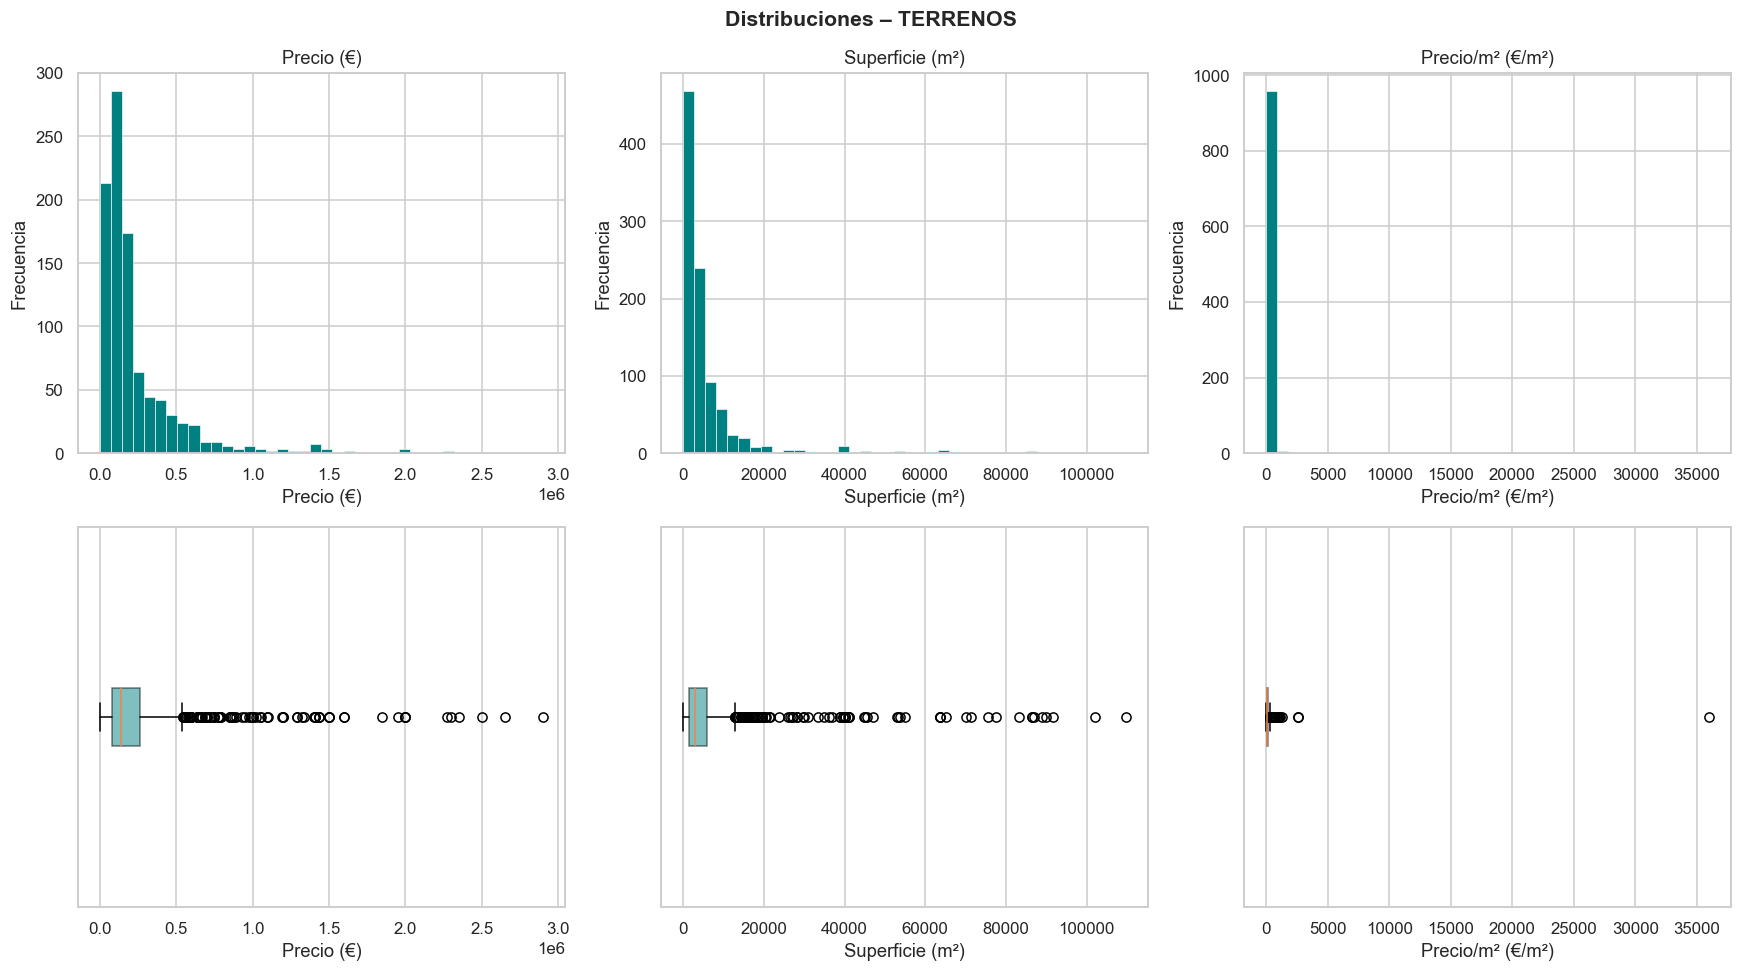

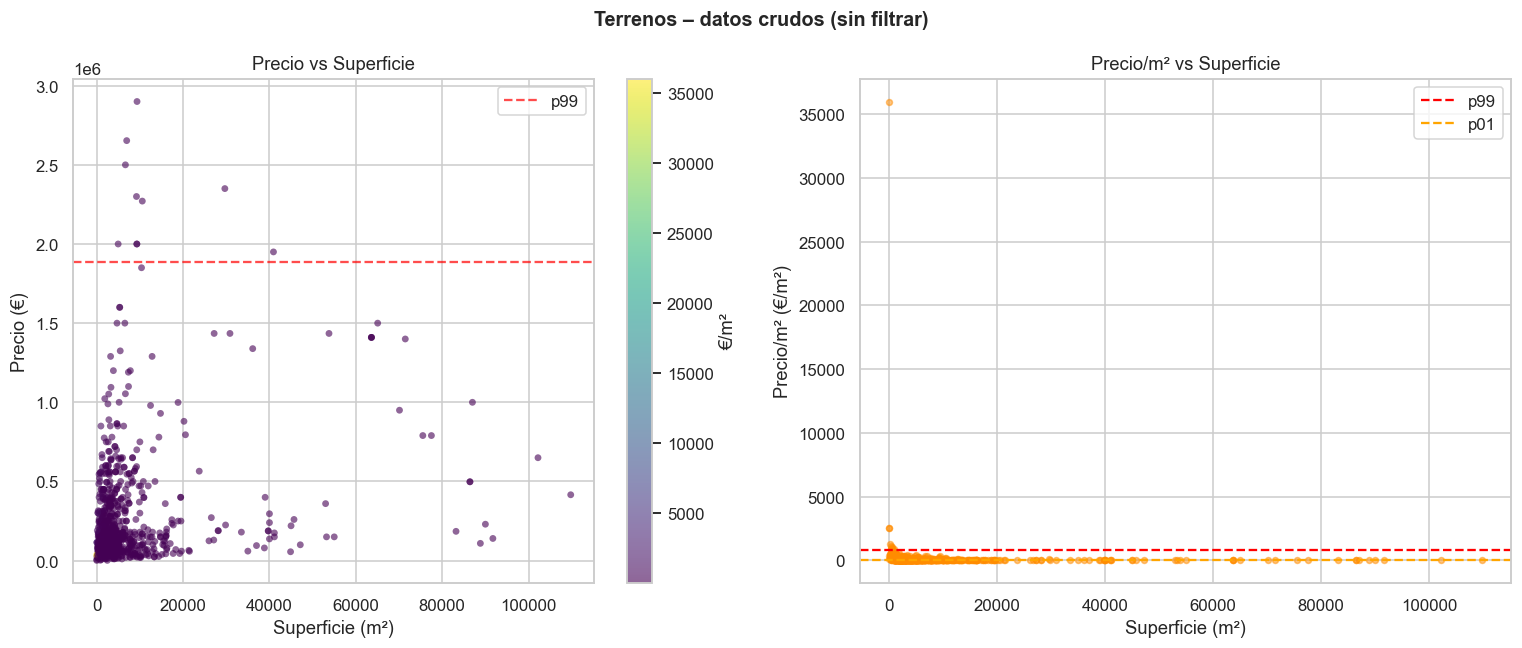

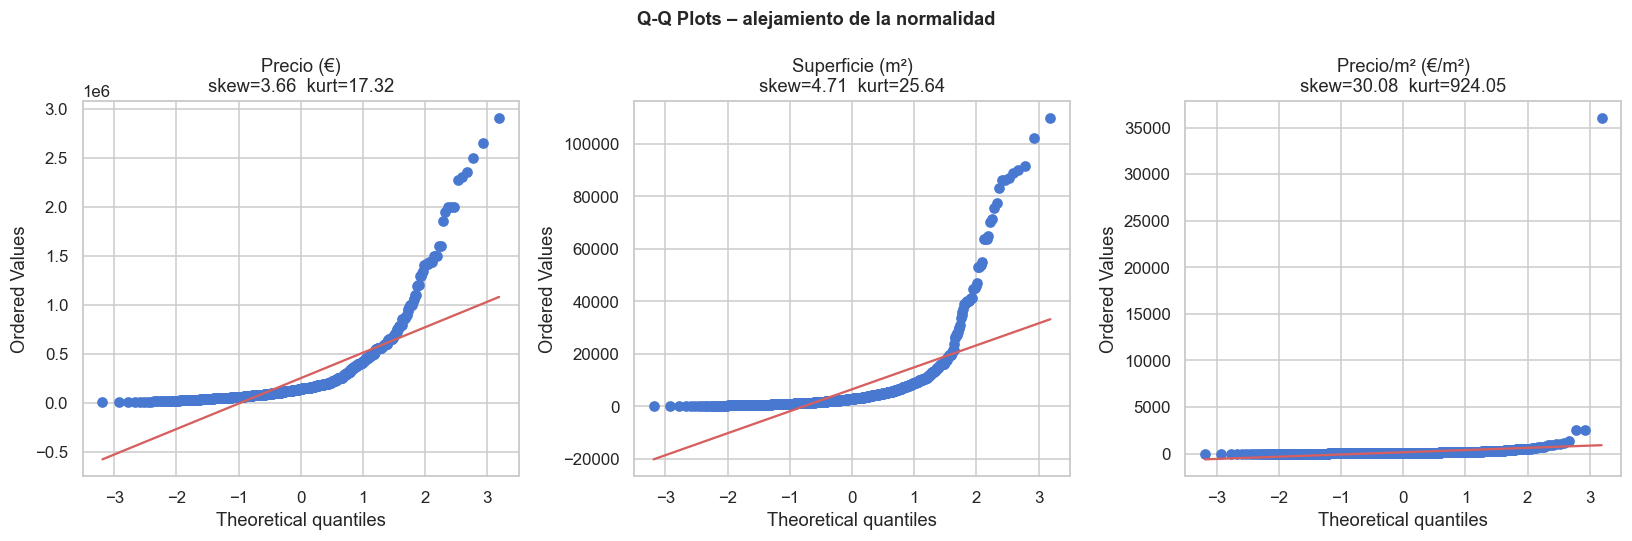

Distribuciones asimétricas (skew > 1) → la regla 3-sigma clásica eliminará demasiado.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── Distribuciones ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribuciones – TERRENOS', fontsize=14, fontweight='bold')

cols_eda   = ['precio_eur', 'superficie_m2', 'precio_m2']
labels_eda = ['Precio (€)', 'Superficie (m²)', 'Precio/m² (€/m²)']

for i, (col, label) in enumerate(zip(cols_eda, labels_eda)):
    data = df_final[col].dropna()
    axes[0, i].hist(data, bins=40, color='teal', edgecolor='white', linewidth=0.4)
    axes[0, i].set_title(label)
    axes[0, i].set_xlabel(label)
    axes[0, i].set_ylabel('Frecuencia')
    axes[1, i].boxplot(data, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='teal', alpha=0.5))
    axes[1, i].set_xlabel(label)
    axes[1, i].set_yticks([])

plt.tight_layout()
plt.show()

# ── Scatter precio vs superficie ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Terrenos – datos crudos (sin filtrar)', fontsize=13, fontweight='bold')

sub = df_final.dropna(subset=['precio_eur', 'superficie_m2'])
sc  = axes[0].scatter(sub['superficie_m2'], sub['precio_eur'],
                      c=sub['precio_m2'], cmap='viridis',
                      alpha=0.6, s=20, edgecolors='none')
plt.colorbar(sc, ax=axes[0], label='€/m²')
axes[0].set_title('Precio vs Superficie')
axes[0].set_xlabel('Superficie (m²)')
axes[0].set_ylabel('Precio (€)')
axes[0].axhline(sub['precio_eur'].quantile(0.99), color='red', linestyle='--',
                alpha=0.7, label='p99')
axes[0].legend()

sub2 = df_final.dropna(subset=['precio_m2', 'superficie_m2'])
axes[1].scatter(sub2['superficie_m2'], sub2['precio_m2'], alpha=0.5, s=15, color='darkorange')
axes[1].axhline(sub2['precio_m2'].quantile(0.99), color='red', linestyle='--', label='p99')
axes[1].axhline(sub2['precio_m2'].quantile(0.01), color='orange', linestyle='--', label='p01')
axes[1].set_title('Precio/m² vs Superficie')
axes[1].set_xlabel('Superficie (m²)')
axes[1].set_ylabel('Precio/m² (€/m²)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Q-Q plots + skewness ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Q-Q Plots – alejamiento de la normalidad', fontsize=12, fontweight='bold')

for ax, col, label in zip(axes, cols_eda, labels_eda):
    d = df_final[col].dropna()
    stats.probplot(d, dist='norm', plot=ax)
    ax.set_title(f"{label}\nskew={d.skew():.2f}  kurt={d.kurtosis():.2f}")

plt.tight_layout()
plt.show()
print("Distribuciones asimétricas (skew > 1) → la regla 3-sigma clásica eliminará demasiado.")

---
## Métodos de detección de outliers

Variables analizadas: `precio_eur`, `superficie_m2`, `precio_m2`

| # | Método | Asume normalidad | Variables | Agresividad |
|---|--------|-----------------|-----------|-------------|
| 1 | **Regla fija** | No | Univariante | Configurable |
| 2 | **IQR (1.5×)** | No | Univariante | Media |
| 3 | **Z-score sobre log** | Sí (en log) | Univariante | Baja |
| 4 | **Isolation Forest** | No | Multivariante | Alta (configurable) |

Regla fija:
  [Terrenos]  outliers=71  (7.3%)  → quedan 896

IQR ×1.5:
  [Terrenos]  outliers=224  (23.2%)  → quedan 743
IQR ×3.0:
  [Terrenos]  outliers=121  (12.5%)  → quedan 846

Z-log 3.0σ:
  [Terrenos]  outliers=9  (0.9%)  → quedan 958
Z-log 2.5σ:
  [Terrenos]  outliers=42  (4.3%)  → quedan 925

Isolation Forest contamination=0.05:
  [Terrenos]  outliers=49  (5.1%)  → quedan 918

Isolation Forest contamination=0.02:
  [Terrenos]  outliers=20  (2.1%)  → quedan 947


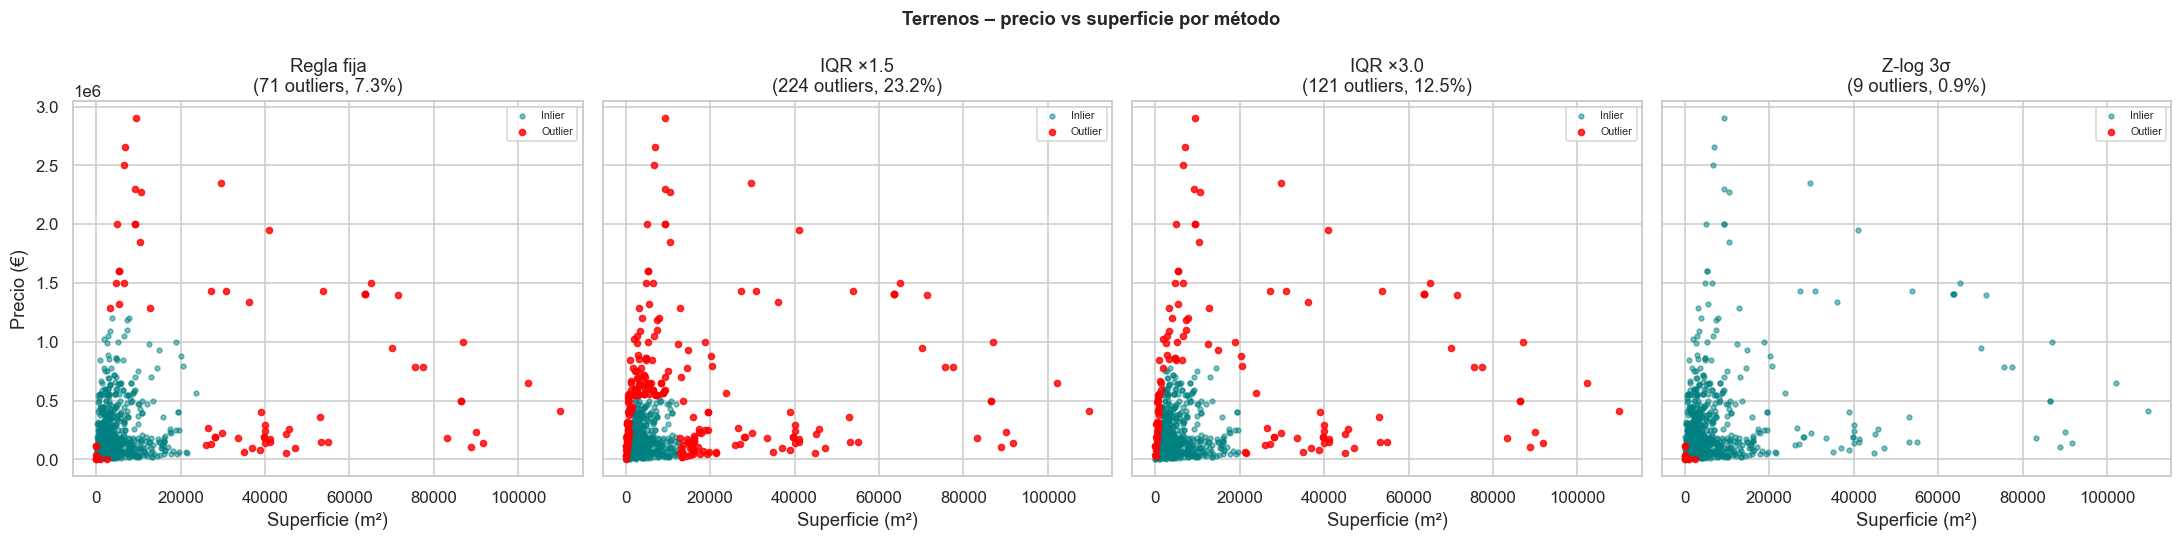

,Outliers,%,Restantes
Método,,,
Regla fija,71,7.3%,896
IQR ×1.5,224,23.2%,743
IQR ×3.0,121,12.5%,846
Z-log 3.0σ,9,0.9%,958
Z-log 2.5σ,42,4.3%,925


In [17]:
# ── Funciones auxiliares ──────────────────────────────────────────────────
def resumen_land(nombre, df_orig, mask_out):
    n = mask_out.sum()
    print(f"  [{nombre}]  outliers={n:,}  ({100*n/len(df_orig):.1f}%)  → quedan {len(df_orig)-n:,}")

def mask_iqr_land(df, cols, factor=1.5):
    mask = pd.Series(False, index=df.index)
    for col in cols:
        d = df[col].dropna()
        q1, q3 = d.quantile(0.25), d.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - factor * iqr, q3 + factor * iqr
        mask |= df[col].notna() & ((df[col] < lower) | (df[col] > upper))
    return mask

def mask_zscore_log_land(df, cols, threshold=3.0):
    mask = pd.Series(False, index=df.index)
    for col in cols:
        series = df[col]
        valid  = series[series > 0].dropna()
        log_v  = np.log(valid)
        z      = (log_v - log_v.mean()) / log_v.std()
        mask |= df.index.isin(z[z.abs() > threshold].index)
    return mask

LAND_COLS = ['precio_eur', 'superficie_m2', 'precio_m2']

# ── Método 1: Regla fija ──────────────────────────────────────────────────
# Umbrales configurables – mercado de suelo en Cantabria
PRECIO_MIN,     PRECIO_MAX     = 5_000,   1_200_000   # €
SUPERFICIE_MIN, SUPERFICIE_MAX = 50,      25_000     # m²
PBM_MIN,        PBM_MAX        = 0.5,     8_000       # €/m²

def mask_rf_land(df):
    return (
        df['precio_eur'].between(PRECIO_MIN, PRECIO_MAX) &
        df['superficie_m2'].between(SUPERFICIE_MIN, SUPERFICIE_MAX) &
        (df['precio_m2'].isna() | df['precio_m2'].between(PBM_MIN, PBM_MAX))
    )

m1_out = ~mask_rf_land(df_final)
print("Regla fija:")
resumen_land('Terrenos', df_final, m1_out)

# ── Método 2: IQR ×1.5 y ×3.0 ────────────────────────────────────────────
m2a_out = mask_iqr_land(df_final, LAND_COLS, 1.5)
m2b_out = mask_iqr_land(df_final, LAND_COLS, 3.0)
print("\nIQR ×1.5:")
resumen_land('Terrenos', df_final, m2a_out)
print("IQR ×3.0:")
resumen_land('Terrenos', df_final, m2b_out)

# ── Método 3: Z-score sobre log ───────────────────────────────────────────
m3a_out = mask_zscore_log_land(df_final, LAND_COLS, 3.0)
m3b_out = mask_zscore_log_land(df_final, LAND_COLS, 2.5)
print("\nZ-log 3.0σ:")
resumen_land('Terrenos', df_final, m3a_out)
print("Z-log 2.5σ:")
resumen_land('Terrenos', df_final, m3b_out)

# ── Método 4: Isolation Forest ────────────────────────────────────────────
from sklearn.ensemble import IsolationForest
sub_if = df_final[LAND_COLS].copy().fillna(df_final[LAND_COLS].median())
for cont in [0.05, 0.02]:
    clf   = IsolationForest(contamination=cont, random_state=42)
    preds = clf.fit_predict(sub_if)
    m4    = pd.Series(preds == -1, index=df_final.index)
    print(f"\nIsolation Forest contamination={cont}:")
    resumen_land('Terrenos', df_final, m4)

# ── Scatter comparativo ───────────────────────────────────────────────────
sub_plot = df_final.dropna(subset=['superficie_m2', 'precio_eur'])
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.suptitle('Terrenos – precio vs superficie por método', fontsize=12, fontweight='bold')

for ax, (mask, label) in zip(axes, [
    (m1_out,  'Regla fija'),
    (m2a_out, 'IQR ×1.5'),
    (m2b_out, 'IQR ×3.0'),
    (m3a_out, 'Z-log 3σ'),
]):
    m = mask.reindex(sub_plot.index).fillna(False)
    ax.scatter(sub_plot.loc[~m, 'superficie_m2'], sub_plot.loc[~m, 'precio_eur'],
               s=10, alpha=0.5, color='teal', label='Inlier')
    ax.scatter(sub_plot.loc[ m, 'superficie_m2'], sub_plot.loc[ m, 'precio_eur'],
               s=16, alpha=0.8, color='red', label='Outlier')
    ax.set_title(f"{label}\n({m.sum()} outliers, {100*m.sum()/len(sub_plot):.1f}%)")
    ax.set_xlabel('Superficie (m²)')
    if ax == axes[0]:
        ax.set_ylabel('Precio (€)')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# ── Tabla resumen ─────────────────────────────────────────────────────────
n0 = len(df_final)
display(pd.DataFrame([{
    'Método':    name,
    'Outliers':  int(m.sum()),
    '%':         f"{100*m.sum()/n0:.1f}%",
    'Restantes': n0 - int(m.sum()),
} for name, m in [
    ('Regla fija', m1_out), ('IQR ×1.5', m2a_out), ('IQR ×3.0', m2b_out),
    ('Z-log 3.0σ', m3a_out), ('Z-log 2.5σ', m3b_out),
]]).set_index('Método'))

---
## Recomendación y discusión

### Contexto: distribución de los terrenos
Los terrenos son intrínsecamente heterogéneos: un solar urbano de 200 m² y una finca rústica de 50.000 m² coexisten en el mismo dataset. Esto hace que las distribuciones sean muy asimétricas (skewness alto) y que los métodos que asumen normalidad fallen.

### Comparativa de métodos

| Método | Ventaja | Inconveniente | Mejor para |
|--------|---------|--------------|------------|
| **Regla fija** | Permite aplicar conocimiento de dominio | Requiere calibración manual | Primera barrera de errores graves |
| **IQR ×1.5** | Estándar, sin supuestos | Muy agresivo: elimina terrenos grandes legítimos | Distribuciones compactas |
| **IQR ×3.0** | Conservador, respeta la heterogeneidad | Puede dejar algún error de precio | ✅ **Buena opción general** |
| **Z-log** | Maneja distribuciones sesgadas | Menos intuitivo | Alta asimetría en precio |
| **Isolation Forest** | Detecta combinaciones anómalas | Poco interpretable | Control de calidad final |

### Pipeline elegido: Regla fija → IQR ×3.0

Se aplican **dos pasos en secuencia** sobre una copia de `df_final`:

1. **Regla fija** – elimina errores manifiestos: precio ≤ 0, superficie ≤ 0, precio/m² fuera de rangos razonables para suelo cántabro.
2. **IQR ×3.0** – elimina los casos estadísticamente extremos en `precio_eur`, `superficie_m2` y `precio_m2`, respetando la variabilidad natural del mercado de suelo.

---
## Pipeline final: Regla fija → IQR ×3.0 y exportación

Original: 967 registros

Paso 1 – Regla fija:
  967 → 896  (eliminados: 71)

Paso 2 – IQR ×3.0:
  896 → 828  (eliminados: 68)

TOTAL eliminados: 139  (14.4%)


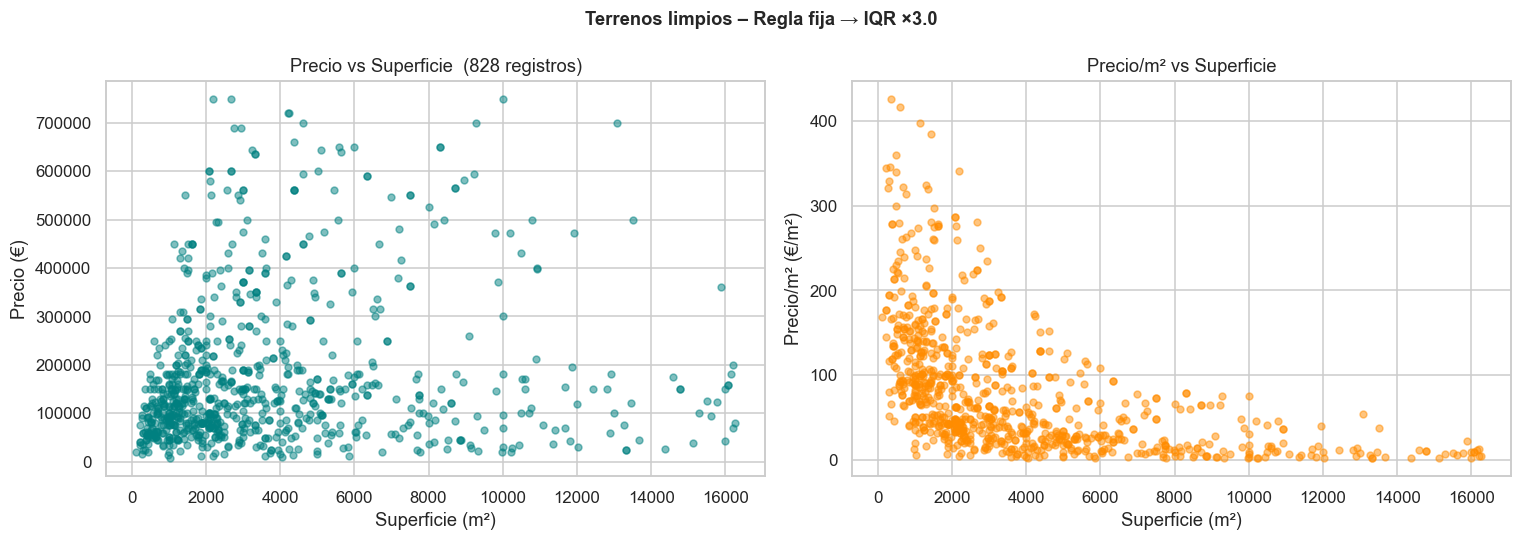

In [18]:
# ── Paso 0: copia de df_final (no se modifica en disco) ───────────────────
land_pipe = df_final.copy()
print(f"Original: {len(land_pipe):,} registros")

# ── Paso 1: Regla fija ────────────────────────────────────────────────────
land_paso1 = land_pipe[mask_rf_land(land_pipe)].reset_index(drop=True)
elim_rf    = len(land_pipe) - len(land_paso1)
print(f"\nPaso 1 – Regla fija:")
print(f"  {len(land_pipe):,} → {len(land_paso1):,}  (eliminados: {elim_rf:,})")

# ── Paso 2: IQR ×3.0 sobre el resultado del paso 1 ───────────────────────
IQR_COLS_LAND = ['precio_eur', 'superficie_m2', 'precio_m2']
IQR_FACTOR    = 3.0

mask_iqr2    = mask_iqr_land(land_paso1, IQR_COLS_LAND, IQR_FACTOR)
df_land_clean = land_paso1[~mask_iqr2].reset_index(drop=True)
elim_iqr = len(land_paso1) - len(df_land_clean)
print(f"\nPaso 2 – IQR ×{IQR_FACTOR}:")
print(f"  {len(land_paso1):,} → {len(df_land_clean):,}  (eliminados: {elim_iqr:,})")
print(f"\nTOTAL eliminados: {elim_rf + elim_iqr:,}  ({100*(elim_rf+elim_iqr)/len(land_pipe):.1f}%)")

# ── Scatter post-pipeline ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Terrenos limpios – Regla fija → IQR ×3.0', fontsize=12, fontweight='bold')

axes[0].scatter(df_land_clean['superficie_m2'], df_land_clean['precio_eur'],
                alpha=0.5, s=20, color='teal')
axes[0].set_title(f'Precio vs Superficie  ({len(df_land_clean):,} registros)')
axes[0].set_xlabel('Superficie (m²)')
axes[0].set_ylabel('Precio (€)')

axes[1].scatter(df_land_clean['superficie_m2'], df_land_clean['precio_m2'],
                alpha=0.5, s=20, color='darkorange')
axes[1].set_title('Precio/m² vs Superficie')
axes[1].set_xlabel('Superficie (m²)')
axes[1].set_ylabel('Precio/m² (€/m²)')

plt.tight_layout()
plt.show()

In [19]:
# EXPORT_PROCESSED_TERRENOS
from pathlib import Path

# Validacion simple: primero hay que ejecutar las celdas de limpieza y el pipeline de outliers.
if "df_land_clean" not in globals():
    raise NameError("No existe df_land_clean. Ejecuta antes las celdas de limpieza y la sección del pipeline.")

# Ruta robusta a data/processed (funciona desde raiz o desde notebooks/...).
processed_base_candidates = [
    Path("data/processed"),
    Path("../../data/processed")
]
processed_base = next((p for p in processed_base_candidates if p.exists()), Path("data/processed"))

# Creamos la carpeta objetivo dentro de processed.
processed_dir = processed_base / "scraping_manual"
processed_dir.mkdir(parents=True, exist_ok=True)

# Exportamos el resultado limpio tras la eliminación de outliers.
output_path = processed_dir / "scraping_land_processed.csv"
df_land_clean.to_csv(output_path, sep=';', index=False, encoding='utf-8')

print(f"Dataset exportado en: {output_path.resolve()}")
print(f"Registros: {len(df_land_clean):,}")

Dataset exportado en: /Users/sitomachucas/Documents/BezanillaSL/data/processed/scraping_manual/scraping_land_processed.csv
Registros: 828
